# Static Parameter Identifier

In [1]:
# 处理全部范围的数据

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
from tqdm import tqdm
import math
import rootpath
import sys
from pathlib import Path
root_dir = rootpath.detect()   # Get the root directory of the project (.git)
sys.path.append(str(Path(root_dir)))
from utils.experiment import MujocoExperiment


In [3]:
# Load Real Date
data = pd.read_csv("../tmpdata/real(all)_StaticPoint_6group_2025-02-21_08-55-07_2025-07-27_18-22-52.csv")
P1_actual = np.array(data['P1 (kPa)'].values, dtype=np.float32) * 1000
P2_actual = np.array(data['P2 (kPa)'].values, dtype=np.float32) * 1000
theta1 = np.array(data['theta1 (deg)'].values, dtype=np.float32) * np.pi / 180
theta2 = np.array(data['theta2 (deg)'].values, dtype=np.float32) * np.pi / 180
data

,P1 (kPa),P2 (kPa),theta1 (deg),theta2 (deg)
0,0.0,0.0,73.0852,61.3880
1,0.0,10.0,74.5715,45.4226
2,0.0,20.0,73.5057,29.5659
3,0.0,30.0,74.0822,12.3551
4,0.0,40.0,74.1967,-1.7623
5,0.0,50.0,67.5935,-1.2435
6,10.0,0.0,84.2280,49.4360
7,10.0,10.0,84.3197,31.1928
8,10.0,20.0,85.8158,11.4137
9,10.0,30.0,85.1966,-1.8447


In [4]:
# make the data from the geometry model
def get_geom_data(theta_1, theta_2):
    '''
        return: 
            Y_mat (transpose): np.ndarray, shape (2, 4), the matrix containing partial derivatives of y with respect to the masses
            L_mat (transpose): np.ndarray, shape (2, 2), the matrix containing partial derivatives of lengths with respect to the angles
            l1: float, the length of the first segment
            l2: float, the length of the second segment
    '''
    # fix the parameters
    a_1, a_2, b_1, b_2, d_1, d_2 = 0.25, 0.25, 0.21213, 0.1, 0.06, 0.10
    beta_1, beta_2 = 8.13 / 180 * math.pi, 30 / 180 * math.pi
    g = 9.8

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * math.cos(theta_1 - beta_1)
    C_y_O = b_1 * math.sin(theta_1 - beta_1)

    D_x_O = a_1 * math.cos(theta_1) + b_2 * math.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * math.sin(theta_1) + b_2 * math.sin(theta_1 + theta_2 + beta_2)

    E_x_O = a_1 * math.cos(theta_1)
    E_y_O = a_1 * math.sin(theta_1)

    F_x_O = a_1 * math.cos(theta_1) + a_2 * math.cos(theta_1 + theta_2)
    F_y_O = a_1 * math.sin(theta_1) + a_2 * math.sin(theta_1 + theta_2)

    # Compute partial derivatives
    # Partial derivatives with respect to theta_1

    dA_x_O_dtheta_1 = 0
    dA_y_O_dtheta_1 = 0

    dB_x_O_dtheta_1 = 0
    dB_y_O_dtheta_1 = 0

    dC_x_O_dtheta_1 = -b_1 * math.sin(theta_1 - beta_1)
    dC_y_O_dtheta_1 = b_1 * math.cos(theta_1 - beta_1)

    dD_x_O_dtheta_1 = -a_1 * math.sin(theta_1) - b_2 * math.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_1 = a_1 * math.cos(theta_1) + b_2 * math.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_1 = -a_1 * math.sin(theta_1)
    dE_y_O_dtheta_1 = a_1 * math.cos(theta_1)

    dF_x_O_dtheta_1 = -a_1 * math.sin(theta_1) - a_2 * math.sin(theta_1 + theta_2)
    dF_y_O_dtheta_1 = a_1 * math.cos(theta_1) + a_2 * math.cos(theta_1 + theta_2)

    # Partial derivatives with respect to theta_2

    dA_x_O_dtheta_2 = 0.0
    dA_y_O_dtheta_2 = 0.0

    dB_x_O_dtheta_2 = 0.0
    dB_y_O_dtheta_2 = 0.0

    dC_x_O_dtheta_2 = 0.0
    dC_y_O_dtheta_2 = 0.0

    dD_x_O_dtheta_2 = -b_2 * math.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_2 = b_2 * math.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_2 = 0.0
    dE_y_O_dtheta_2 = 0.0

    dF_x_O_dtheta_2 = -a_2 * math.sin(theta_1 + theta_2)
    dF_y_O_dtheta_2 = a_2 * math.cos(theta_1 + theta_2)

    l_1 = math.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = math.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    # Compute partial derivatives
    # Partial derivatives d/dtheta_1
    dl_1_dtheta_1 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_1 - dC_x_O_dtheta_1) + (A_y_O - C_y_O) * (dA_y_O_dtheta_1 - dC_y_O_dtheta_1))
    dl_2_dtheta_1 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_1 - dD_x_O_dtheta_1) + (B_y_O - D_y_O) * (dB_y_O_dtheta_1 - dD_y_O_dtheta_1))

    # Partial derivatives d/dtheta_2
    dl_1_dtheta_2 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_2 - dC_x_O_dtheta_2) + (A_y_O - C_y_O) * (dA_y_O_dtheta_2 - dC_y_O_dtheta_2))
    dl_2_dtheta_2 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_2 - dD_x_O_dtheta_2) + (B_y_O - D_y_O) * (dB_y_O_dtheta_2 - dD_y_O_dtheta_2))

    # print(dl_1_dtheta_2)  # check the model

    Y_mat = np.array([
        [(dE_y_O_dtheta_1/2), ((dE_y_O_dtheta_1+dF_y_O_dtheta_1)/2), (dC_y_O_dtheta_1/2), (dD_y_O_dtheta_1/2)], 
        [(dE_y_O_dtheta_2/2), ((dE_y_O_dtheta_2+dF_y_O_dtheta_2)/2), (dC_y_O_dtheta_2/2), (dD_y_O_dtheta_2/2)]])

    L_mat = np.array([
        [dl_1_dtheta_1, dl_2_dtheta_1],
        [dl_1_dtheta_2, dl_2_dtheta_2]])
    # NOTE: Note that this is already transposed!

    return Y_mat, L_mat, l_1, l_2


In [5]:
# # Construct the data and Do regressions
# m1, m2, m3, m4 = 0.086, 0.1033, 186.48 * 1e-3, 272.66 * 1e-3
# g = 9.8
# m_array =  np.array([m1, m2, m3, m4])

# Y_mat_list = []
# L_mat_list = []
# l1_list = []
# l2_list = []
# GLYM_list = []

# for t1, t2 in zip(theta1, theta2):
#     Y_mat, L_mat, l_1, l_2 = get_geom_data(t1, t2)
#     GLYM = -g*np.linalg.inv(L_mat)@Y_mat@m_array
#     Y_mat_list.append(Y_mat)
#     L_mat_list.append(L_mat)
#     l1_list.append(l_1)
#     l2_list.append(l_2)
#     GLYM_list.append(GLYM)

# Y_mat_array = np.array(Y_mat_list)
# L_mat_array = np.array(L_mat_list)
# l1_array = np.array(l1_list)
# l2_array = np.array(l2_list)
# GLYM_array = np.array(GLYM_list)  # Shape: (13, 2), first column corresponds to P1, second column corresponds to P2

# l10_set, l20_set = 0.1740, 0.2562

# # Perform parameter identification using least squares method
# A1 = np.stack([l1_array-l10_set*np.ones_like(l1_array), GLYM_array[:,0]], axis=1)   # NOTE: axis=1 means spand 13 to (13, 1)
# # Returns: x: Least-squares solution. residuals: Sums of squared residuals. rank: Rank of matrix a. s: Singular values of a.
# # A1 = np.stack([l1_array, -np.ones_like(l1_array), GLYM_array[:,0]], axis=1)
# x1, residuals1, rank, s = np.linalg.lstsq(A1, P1_actual, rcond=None)
# s1_ans = 1/x1[-1]
# k1_ans = x1[0]/x1[-1]
# print(f"s1_ans: {s1_ans.round(6)}, k1_ans: {k1_ans.round(4)}")

# A2 = np.stack([l2_array-l20_set*np.ones_like(l2_array), GLYM_array[:,1]], axis=1)
# # A2 = np.stack([l2_array, -np.ones_like(l1_array), GLYM_array[:,1]], axis=1)
# x2, residuals2, rank, s = np.linalg.lstsq(A2, P2_actual, rcond=None)
# s2_ans = 1/x2[-1]
# k2_ans = x2[0]/x2[-1]
# print(f"s2_ans: {s2_ans.round(6)}, k2_ans: {k2_ans.round(4)}")

# # Save the results
# pressure_error_summary = pd.DataFrame()
# pressure_error_summary['P1_actual/kPa'] = (P1_actual / 1000).round(4)
# pressure_error_summary['P2_actual/kPa'] = (P2_actual / 1000).round(4)
# pressure_error_summary['P1_error/kPa'] = ((P1_actual - A1 @ x1) / 1000).round(4)
# pressure_error_summary['P2_error/kPa'] = ((P2_actual - A2 @ x2) / 1000).round(4)
# pressure_error_summary.to_csv('./data/pressure_error_summary.csv', index=False)

In [6]:
# # If we use the measured data directly, the error is too large
# x1_guess = np.array([318.76/(6.54*1e-4), 1/(6.54*1e-4)])
# x2_guess = np.array([315.80/(6.37*1e-4), 1/(6.37*1e-4)])
# print(f"P1_error (original measured data used): {A1@x1_guess/1000-P1_actual/1000}")
# print(f"P2_error (original measured data used): {A2@x2_guess/1000-P2_actual/1000}")

In [11]:
# NOTE: 这里取的参数为用工作空间辨识得到的结果，可以用来检查泛化性
s1_ans = 0.000411
k1_ans = 203.9489
s2_ans = 0.000324
k2_ans = 105.0733

# Cross check: Use the simulation result to make comparison with the real data
path = (root_dir + "/models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml")
exp = MujocoExperiment(path)
experiment_instance = MujocoExperiment(path)
para = {
    'stiffness_MAA': k1_ans, # 637.52 / 2,
    'stiffness_BAA': k2_ans, # 631.6 / 2,
    'l10': 0.174,
    'l20': 0.2562,
    'damping_MAA': 11.34,
    'damping_BAA': 10.90,
    'c1_thigh': 0,
    'c2_calf': 0,
    's1': s1_ans,
    's2': s2_ans,
    'P1': 0,        # To be set
    'P2': 0,
    'P1_prime': 0.0,      
    'P2_prime': 0.0       # equal to F when s=1
}
simulated_static_state = []
for i in range(len(P1_actual)):
    para['P1_prime'] = P1_actual[i]
    para['P2_prime'] = P2_actual[i]

    # Run the experiment
    time_step = 0.0001
    duration_exp = 5.0

    # Run the simulation
    time_sim, theta1_sim, theta2_sim, frames, _, _ = experiment_instance.run(para, time_step=time_step, duration=duration_exp, ifrender=False)
    # Save the simulation result
    simulated_static_state.append([theta1_sim[-1], theta2_sim[-1]])

# Convert the simulated static state to numpy array
simulated_static_state = np.array(simulated_static_state)
# Calculate the error
error_theta1 = simulated_static_state[:, 0] - theta1
error_theta2 = simulated_static_state[:, 1] - theta2
# Save in pd.DataFrame
simulated_static_state_df = pd.DataFrame()
simulated_static_state_df['P1_actual/kPa'] = P1_actual/1000
simulated_static_state_df['P2_actual/kPa'] = P2_actual/1000
simulated_static_state_df['theta1_real/rad'] = theta1.round(4)
simulated_static_state_df['theta2_real/rad'] = theta2.round(4)
simulated_static_state_df['theta1_sim/rad'] = simulated_static_state[:, 0].round(4)
simulated_static_state_df['theta2_sim/rad'] = simulated_static_state[:, 1].round(4)
simulated_static_state_df['theta1_error/rad'] = error_theta1.round(4)
simulated_static_state_df['theta2_error/rad'] = error_theta2.round(4)
simulated_static_state_df.to_csv('./data/simulated_static_state_error_all.csv', index=False)
simulated_static_state_df

,P1_actual/kPa,P2_actual/kPa,theta1_real/rad,theta2_real/rad,theta1_sim/rad,theta2_sim/rad,theta1_error/rad,theta2_error/rad
0,0.0,0.0,1.2756,1.0714,1.2939,1.0412,0.0184,-0.0303
1,0.0,10.0,1.3015,0.7928,1.2997,0.7595,-0.0019,-0.0333
2,0.0,20.0,1.2829,0.5160,1.3079,0.4646,0.0250,-0.0515
3,0.0,30.0,1.2930,0.2156,1.3086,0.1636,0.0156,-0.0521
4,0.0,40.0,1.2950,-0.0308,1.2538,0.0002,-0.0412,0.0310
5,0.0,50.0,1.1797,-0.0217,1.1491,-0.0007,-0.0306,0.0211
6,10.0,0.0,1.4701,0.8628,1.4530,0.8816,-0.0171,0.0188
7,10.0,10.0,1.4717,0.5444,1.4623,0.5816,-0.0093,0.0372
8,10.0,20.0,1.4978,0.1992,1.4718,0.2633,-0.0259,0.0641
9,10.0,30.0,1.4870,-0.0322,1.4496,0.0005,-0.0374,0.0327


In [31]:
# 处理数据点
import matplotlib.pyplot as plt
static_analysis_data_all = pd.read_csv("./data/simulated_static_state_error_all.csv")
static_analysis_data_effective = pd.read_csv("./data/simulated_static_state_error_effective.csv")

# make rank, as temporal x label, define rank=int(df['P1_actual/kPa']/10) * 5 + int(df['P2_actual/kPa']/10)
_df = static_analysis_data_all
static_analysis_data_all = _df.assign(rank=_df['P1_actual/kPa']//10 * 6 + _df['P2_actual/kPa']//10)

_df = static_analysis_data_effective
static_analysis_data_effective = _df.assign(rank=_df['P1_actual/kPa']//10 * 6 + _df['P2_actual/kPa']//10)

# plt.plot(static_analysis_data_all["theta1_real/rad"]*180/math.pi, label=r"$\theta_1 real$")
# plt.plot(static_analysis_data_all["theta1_sim/rad"]*180/math.pi, label=r"$\theta_1 sim$")
# plt.plot(static_analysis_data_all["theta2_real/rad"]*180/math.pi, label=r"$\theta_2 real$")
# plt.plot(static_analysis_data_all["theta2_sim/rad"]*180/math.pi, label=r"$\theta_2 sim$")
# # plt.plot(static_analysis_data_effective["theta1_real/rad"])

# plt.legend()
static_analysis_data_effective

,P1_actual/kPa,P2_actual/kPa,theta1_real/rad,theta2_real/rad,theta1_sim/rad,theta2_sim/rad,theta1_error/rad,theta2_error/rad,rank
0,0.0,0.0,1.2756,1.0714,1.2939,1.0412,0.0184,-0.0303,0.0
1,0.0,10.0,1.3015,0.7928,1.2997,0.7591,-0.0018,-0.0337,1.0
2,0.0,20.0,1.2829,0.5160,1.3080,0.4637,0.0250,-0.0523,2.0
3,0.0,30.0,1.2930,0.2156,1.3086,0.1624,0.0156,-0.0533,3.0
4,10.0,0.0,1.4701,0.8628,1.4529,0.8816,-0.0171,0.0188,6.0
5,10.0,10.0,1.4717,0.5444,1.4623,0.5813,-0.0093,0.0369,7.0
6,10.0,20.0,1.4978,0.1992,1.4718,0.2625,-0.0259,0.0633,8.0
7,20.0,0.0,1.6181,0.6956,1.6122,0.7108,-0.0059,0.0152,12.0
8,20.0,10.0,1.6336,0.3438,1.6275,0.3801,-0.0061,0.0363,13.0
9,30.0,0.0,1.7746,0.5192,1.7712,0.5255,-0.0034,0.0063,18.0


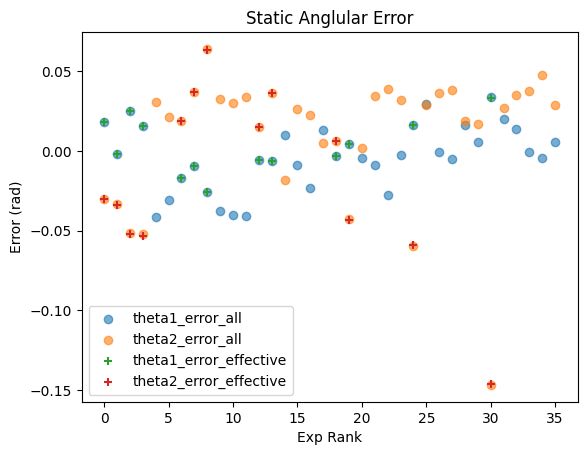

In [62]:
plt.scatter(static_analysis_data_all["rank"], static_analysis_data_all["theta1_error/rad"], label="theta1_error_all", alpha=0.6)
plt.scatter(static_analysis_data_all["rank"], static_analysis_data_all["theta2_error/rad"], label="theta2_error_all", alpha=0.6)

plt.scatter(static_analysis_data_effective["rank"], static_analysis_data_effective["theta1_error/rad"], label="theta1_error_effective", marker="+")
plt.scatter(static_analysis_data_effective["rank"], static_analysis_data_effective["theta2_error/rad"], label="theta2_error_effective", marker="+")
plt.title("Static Anglular Error")
plt.xlabel("Exp Rank")
plt.ylabel("Error (rad)")

plt.legend()

In [63]:
# 计算总RMSE
theta_1_error = static_analysis_data_all["theta1_error/rad"]
theta_2_error = static_analysis_data_all["theta2_error/rad"]
RMSE_theta1 = np.sqrt(np.mean(np.square(theta_1_error)))
RMSE_theta2 = np.sqrt(np.mean(np.square(theta_2_error)))
RMSE_summary = pd.DataFrame()
RMSE_summary["RMSE_theta1"]= [RMSE_theta1]
RMSE_summary["RMSE_theta2"]= [RMSE_theta2]
RMSE_summary.to_csv("./data/RMSE_error_summary(all).csv", index=False)